## STEP 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

sns.set(style="whitegrid")

## STEP 2 — Load Dataset

In [2]:
df = pd.read_csv("titanic_cleaned.csv")
df.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",0.271174,0.2,0.0,A/5 21171,0.111538,True,False,True,False,True
1,3,1,"Heikkinen, Miss. Laina",0.321438,0.0,0.0,STON/O2. 3101282,0.121923,False,False,True,False,True
2,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.434531,0.2,0.0,113803,0.816923,False,False,True,False,False
3,5,0,"Allen, Mr. William Henry",0.434531,0.0,0.0,373450,0.123846,True,False,True,False,True
4,6,0,"Moran, Mr. James",0.346569,0.0,0.0,330877,0.130128,True,True,False,False,True


## STEP 3 — Drop Unnecessary Columns

In [3]:
df = df.drop(["Name", "Ticket"], axis=1)
df.head()

,PassengerId,Survived,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
0,1,0,0.271174,0.2,0.0,0.111538,True,False,True,False,True
1,3,1,0.321438,0.0,0.0,0.121923,False,False,True,False,True
2,4,1,0.434531,0.2,0.0,0.816923,False,False,True,False,False
3,5,0,0.434531,0.0,0.0,0.123846,True,False,True,False,True
4,6,0,0.346569,0.0,0.0,0.130128,True,True,False,False,True


# PART 1 — REGRESSION MODEL

### Predict Fare

## STEP 4 — Define X and y (Regression)

In [4]:
X_reg = df.drop("Fare", axis=1)
y_reg = df["Fare"]

## STEP 5 — Train Test Split

In [5]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

## STEP 6 — Train Linear Regression

In [6]:
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## STEP 7 — Predict

In [7]:
y_pred_reg = reg_model.predict(X_test_reg)

## STEP 8 — Evaluate Regression

In [8]:
r2 = r2_score(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.5497133110608464
RMSE: 0.1641273793081892


## Regression Insights

The Linear Regression model achieved an R² score of 0.55, indicating moderate predictive performance.  
The RMSE value of 0.16 suggests low prediction error due to normalized data.

Overall, the regression model shows decent capability in predicting fare values.

# PART 2 — CLASSIFICATION

### Predict Survived

## STEP 9 — Define X and y (Classification)

In [9]:
X_clf = df.drop("Survived", axis=1)
y_clf = df["Survived"]

## STEP 10 — Train Test Split

In [10]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

## STEP 11 — Train Logistic Regression

In [11]:
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_clf, y_train_clf)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## STEP 12 — Predict

In [12]:
y_pred_clf = clf_model.predict(X_test_clf)

## STEP 13 — Evaluate Classification

In [13]:
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7806451612903226
Precision: 0.782608695652174
Recall: 0.6


## STEP 14 — Confusion Matrix

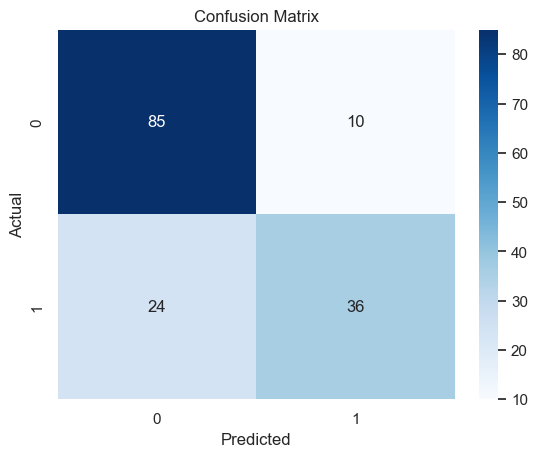

In [14]:
cm = confusion_matrix(y_test_clf, y_pred_clf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Insights

The Logistic Regression model achieved 78% accuracy, indicating strong predictive performance.

Precision score of 0.78 shows the model makes reliable positive predictions.

Recall score of 0.60 indicates that 60% of actual survivors were correctly identified.

Overall, the classification model demonstrates good performance for predicting passenger survival.